# **Transfer Learning :**

It is a DL technique where we use a pre-trained model.This pre-trained model is trained for one task and can be re-trained for a similar task with a smaller dataset.

Transfer Learning gives higher accuracy compared to traning models from scratch.



In [1]:
!pip install kaggle

In [2]:
#Configure the path of Kaggle.json file
!mkdir  -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dog vs Cat Dataset from Kaggle

In [3]:
#it download the dataset in zipfile
!kaggle competitions download -c dogs-vs-cats


 98% 795M/812M [00:03<00:00, 257MB/s]
100% 812M/812M [00:03<00:00, 271MB/s]


In [4]:
!ls


dogs-vs-cats.zip  kaggle.json  sample_data


In [5]:
#extracting the compressed files(datasets)
from zipfile import ZipFile #importing the zipfile function from zipfile
dataset = '/content/dogs-vs-cats.zip'#mentioning the path of thr file
with ZipFile(dataset,'r') as zip: #opening this file and reading it as a zip file
  zip.extractall() #extracting the dataset
  print('The dataset is extracted')


The dataset is extracted


In [6]:
#extracting the compressed files(datasets)
from zipfile import ZipFile #importing the zipfile function from zipfile
dataset = '/content/train.zip'#mentioning the path of thr file
with ZipFile(dataset,'r') as zip: #opening this file and reading it as a zip file
  zip.extractall() #extracting the dataset
  print('The dataset is extracted')


The dataset is extracted


In [7]:
import os
# counting the number of file from train folder
path,dirs,files=next(os.walk('/content/train'))
file_count=len(files) # list containing all the images
print("Number of images",file_count)

Number of images 25000


since wee won't be using all these images as we are using a pre trained model.So,will take a small sample of this and then will be training our model.

In [8]:
#creating a variable naming it as a file_namee which would be  a list
# SO,it will create the all the ditrectories and create a python list means it contains the name of the files

file_name=os.listdir('/content/train')

print(file_name)

['dog.1271.jpg', 'cat.9149.jpg', 'dog.7587.jpg', 'cat.7129.jpg', 'dog.8190.jpg', 'dog.10665.jpg', 'cat.10075.jpg', 'cat.10853.jpg', 'dog.7441.jpg', 'dog.7077.jpg', 'dog.6125.jpg', 'dog.10386.jpg', 'cat.1978.jpg', 'dog.7396.jpg', 'dog.6718.jpg', 'cat.2657.jpg', 'cat.1839.jpg', 'cat.7967.jpg', 'cat.5523.jpg', 'cat.7393.jpg', 'dog.10011.jpg', 'cat.4471.jpg', 'cat.2510.jpg', 'cat.10278.jpg', 'dog.2554.jpg', 'dog.2375.jpg', 'cat.2327.jpg', 'cat.2079.jpg', 'cat.4278.jpg', 'cat.12232.jpg', 'cat.1506.jpg', 'dog.7420.jpg', 'cat.11287.jpg', 'cat.5627.jpg', 'cat.12172.jpg', 'dog.8840.jpg', 'dog.11080.jpg', 'cat.6124.jpg', 'dog.2570.jpg', 'cat.12158.jpg', 'dog.2953.jpg', 'cat.6861.jpg', 'cat.968.jpg', 'dog.6611.jpg', 'dog.9015.jpg', 'dog.1700.jpg', 'dog.3958.jpg', 'dog.10424.jpg', 'cat.7722.jpg', 'cat.3544.jpg', 'dog.6925.jpg', 'cat.7534.jpg', 'cat.11874.jpg', 'dog.3283.jpg', 'dog.2443.jpg', 'dog.2784.jpg', 'dog.6413.jpg', 'cat.4700.jpg', 'dog.10875.jpg', 'dog.9537.jpg', 'cat.395.jpg', 'cat.1736.j

*Importing the dependencies**

In [9]:
import numpy as np
#Resizing the image using the Pillow library
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow



**#DISPLAYING THE IMAGES OF DOG AND CAT**

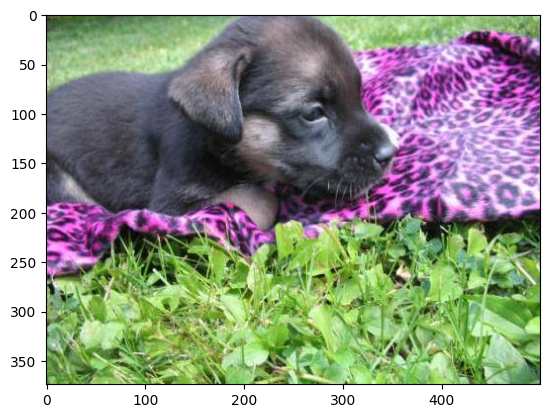

In [10]:
#DISPLAYING THE IMAGES OF DOG
img=mpimg.imread('/content/train/dog.7065.jpg')
imgplot=plt.imshow(img)
plt.show()

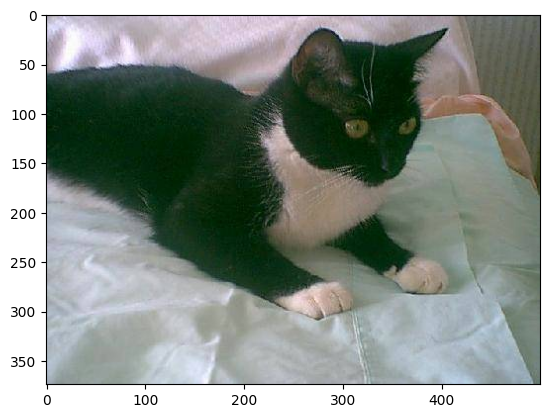

In [11]:
#DISPLAYING THE IMAGES OF cat
img=mpimg.imread('/content/train/cat.3955.jpg')
imgplot=plt.imshow(img)
plt.show()

FINDING HOW MANY CAT AND DOG IMAGES ARE

In [12]:
file_name=os.listdir('/content/train')

for i in range(5):
 name=file_name[i]
 print(name[0:3])


dog
cat
dog
cat
dog


In [13]:
file_name=os.listdir('/content/train')

dog_count=0
cat_count=0

for img_file in file_name:

  name= img_file[0:3]
  if name=='dog':
   dog_count=dog_count+1
  else:
   cat_count=cat_count+1


print("Number of dog image is:",dog_count)
print("Number of cat image is:",cat_count)

Number of dog image is: 12500
Number of cat image is: 12500


all the image should be same shape as we are using MobileNetV2.So,all images should be in 224 pixels in both x and y axes.

RESIZING ALL THE  IMAGES

In [14]:
# creating a directory for resized images
os.makedirs('/content/resized_images', exist_ok=True)

In [15]:
original_folder='/content/train'
resized_folder='/content/resized_images/'

# Get the list of filenames once for efficiency
filenames = os.listdir(original_folder)

for i in range(2000):
  filename = filenames[i]# here I is the index of the this list
  # Use os.path.join to correctly concatenate the folder and filename
  img_path = os.path.join(original_folder, filename)

  img = Image.open(img_path)
  img=img.resize((224,224))
  img=img.convert('RGB')

  newImgPath = os.path.join(resized_folder, filename)
  img.save(newImgPath)

In [16]:
file_name=os.listdir('/content/resized_images/')

dog_count=0
cat_count=0

for img_file in file_name:

  name= img_file[0:3]
  if name=='dog':
   dog_count=dog_count+1
  else:
   cat_count=cat_count+1


print("Number of dog image is:",dog_count)
print("Number of cat image is:",cat_count)

Number of dog image is: 1015
Number of cat image is: 985


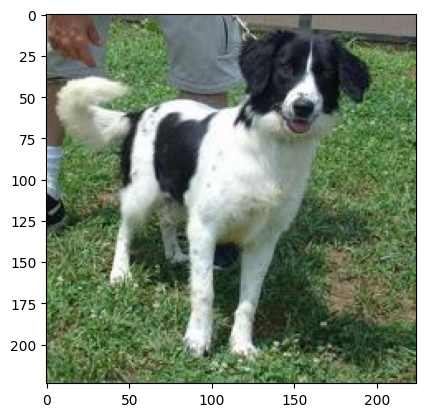

In [18]:
# display resized dog image

img=mpimg.imread('/content/resized_images/dog.10665.jpg')
imgplot=plt.imshow(img)
plt.show()

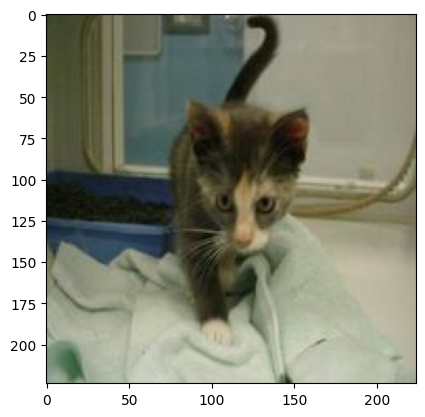

In [19]:
# display resized cat image

img=mpimg.imread('/content/resized_images/cat.7129.jpg')
imgplot=plt.imshow(img)
plt.show()

# **Now createing labels for dogs and cat image**

Cat----> 0
Dog----> 1

In [20]:
# creating a for loop to assign labels

labels = []
for file_path in files: # Iterate over the sorted list of image paths
  file_name = os.path.basename(file_path)
  label_prefix = file_name[0:3] # Extract the prefix from the current filename

  if label_prefix=='dog':
    labels.append(1)
  else: # Assuming it must be 'cat' if not 'dog' based on dataset
    labels.append(0)

In [21]:
print(files[0:5]) # Use the sorted 'files' list for verification

['dog.1271.jpg', 'cat.9149.jpg', 'dog.7587.jpg', 'cat.7129.jpg', 'dog.8190.jpg']


In [22]:
print(len(files)) # Use the sorted 'files' list for verification

25000


In [23]:
print(labels[0:5])
print(len(labels))

[1, 0, 1, 0, 1]
25000


In [24]:
#counting the images of dogs and cats out of 2000 images
values,counts=np.unique(labels,return_counts=True)
print(values)
print(counts)

[0 1]
[12500 12500]


# **Converting all the resized images into numpy array**

In [25]:
import cv2#open cv library
import glob

In [26]:
import glob

image_directory='/content/resized_images/'
image_extension=['png','jpg']

files = []
for ext in image_extension:
    files.extend(glob.glob(image_directory + '*.' + ext))

files.sort() # Ensure consistent order

In [27]:
dog_cat_images= np.asarray([cv2.imread(file) for file in files])

In [28]:
print(dog_cat_images)

[[[[149 146 142]
   [149 146 142]
   [150 145 142]
   ...
   [108  97  83]
   [116 107  94]
   [135 126 113]]

  [[150 147 143]
   [149 146 142]
   [150 145 142]
   ...
   [108  97  83]
   [121 112  99]
   [144 135 122]]

  [[151 148 144]
   [150 147 143]
   [151 146 143]
   ...
   [108  97  83]
   [129 120 107]
   [159 150 137]]

  ...

  [[172 187 190]
   [174 189 192]
   [177 192 195]
   ...
   [250 250 250]
   [242 242 242]
   [233 233 233]]

  [[168 183 186]
   [174 189 192]
   [179 194 197]
   ...
   [250 250 250]
   [243 243 243]
   [235 235 235]]

  [[166 181 184]
   [174 189 192]
   [182 197 200]
   ...
   [250 250 250]
   [245 245 245]
   [237 237 237]]]


 [[[ 26  23  32]
   [ 26  23  32]
   [ 26  23  32]
   ...
   [  4   7  21]
   [  3   6  20]
   [  3   6  20]]

  [[ 48  45  54]
   [ 47  44  53]
   [ 46  43  52]
   ...
   [  4   7  21]
   [  3   6  20]
   [  3   6  20]]

  [[ 78  75  84]
   [ 76  73  82]
   [ 73  70  79]
   ...
   [  5   8  23]
   [  4   7  22]
   [  3   6

In [29]:
type(dog_cat_images)

numpy.ndarray

In [30]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [31]:
X=dog_cat_images

# Regenerate labels to match the 2000 resized images that are in 'files'
# The 'files' variable currently holds paths to the 2000 resized images after cell ssjqt-ibI17x
new_labels = []
for file_path in files:
  file_name = os.path.basename(file_path)
  label_prefix = file_name[0:3]

  if label_prefix=='dog':
    new_labels.append(1)
  else:
    new_labels.append(0)

Y = np.asarray(new_labels) # Y should now have 2000 entries, matching X

# **TRAIN TEST SPLIT **

In [32]:
# random_state=2 split the data in the similar way
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [33]:
print(X.shape,X_train.shape,X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600---->Traning images
400------>Testing images

In [34]:
#sacaling the data means as we have pixel value bit higher so if scale the data betweeen 0-1
# DO NOT SCALE
X_train_final = X_train / 255.0
X_test_final  = X_test / 255.0
print(X_train_final)

[[[[0.13333333 0.14901961 0.15294118]
   [0.13333333 0.14901961 0.15294118]
   [0.13333333 0.14901961 0.15294118]
   ...
   [0.05882353 0.06666667 0.06666667]
   [0.05882353 0.06666667 0.06666667]
   [0.05882353 0.06666667 0.06666667]]

  [[0.13333333 0.14901961 0.15294118]
   [0.13333333 0.14901961 0.15294118]
   [0.13333333 0.14901961 0.15294118]
   ...
   [0.05882353 0.06666667 0.06666667]
   [0.05882353 0.06666667 0.06666667]
   [0.05882353 0.06666667 0.06666667]]

  [[0.13333333 0.14901961 0.15294118]
   [0.13333333 0.14901961 0.15294118]
   [0.13333333 0.14901961 0.15294118]
   ...
   [0.05882353 0.06666667 0.06666667]
   [0.05882353 0.06666667 0.06666667]
   [0.05882353 0.06666667 0.06666667]]

  ...

  [[0.77647059 0.76862745 0.7254902 ]
   [0.76470588 0.75686275 0.71372549]
   [0.75294118 0.74509804 0.70196078]
   ...
   [0.42352941 0.41568627 0.38431373]
   [0.41960784 0.41176471 0.38039216]
   [0.4        0.39215686 0.36078431]]

  [[0.79215686 0.78431373 0.74117647]
   [0.7

**Building the Neural Network**

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models#

In [36]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # ❗ remove original classifier
    weights='imagenet'
)

base_model.trainable = False  # freeze backbone

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [64]:
num_classes = 2  # change if needed

inputs = tf.keras.Input(shape=(224, 224, 3))

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Feature extraction
x = base_model(x, training=False)

# Custom classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [65]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  # Changed to sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,330 (9.26 MB)

 Trainable params: 166,786 (651.51 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [66]:


history = model.fit(
    X_train,          # ✅ raw images (0–255)
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8969 - loss: 0.2805 - val_accuracy: 0.9500 - val_loss: 0.1196
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9830 - loss: 0.0594 - val_accuracy: 0.9575 - val_loss: 0.1151
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9899 - loss: 0.0274 - val_accuracy: 0.9800 - val_loss: 0.0608
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9898 - loss: 0.0234 - val_accuracy: 0.9825 - val_loss: 0.0474
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9956 - loss: 0.0153 - val_accuracy: 0.9900 - val_loss: 0.0475
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9911 - loss: 0.0287 - val_accuracy: 0.9750 - val_loss: 0.0626
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9951 - loss: 0.0136 - val_accuracy: 0.9775 - val_loss: 0.0549
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9951 - loss: 0.0185 - val_accuracy: 0.9675 - val_l

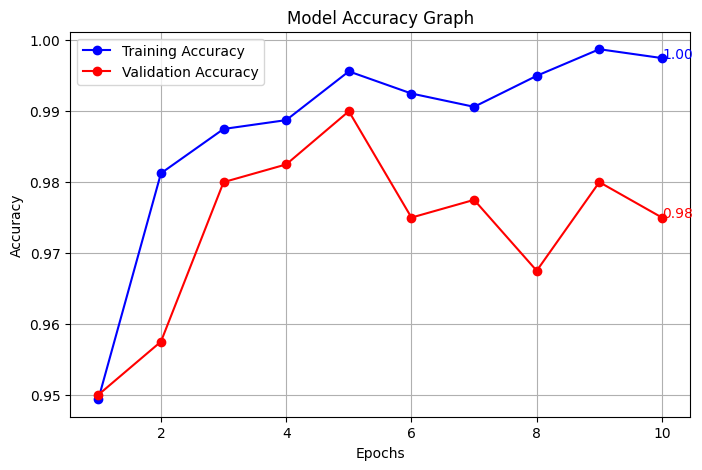

In [69]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')

# 🔹 Last epoch accuracy values show karna
plt.text(epochs[-1], train_acc[-1],
         f"{train_acc[-1]:.2f}", color='blue')
plt.text(epochs[-1], val_acc[-1],
         f"{val_acc[-1]:.2f}", color='red')

plt.title('Model Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

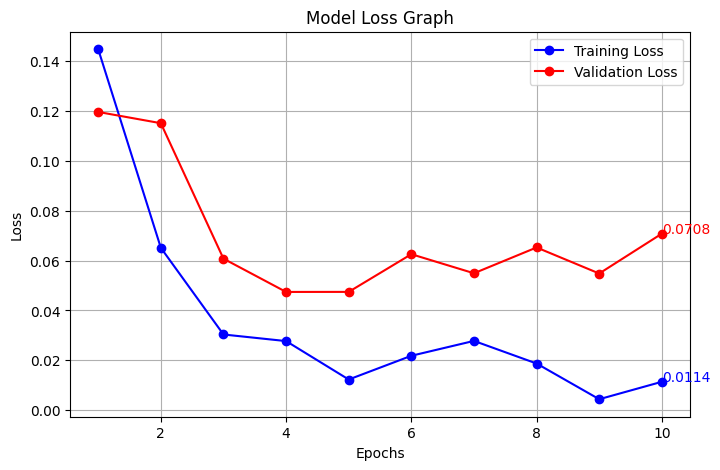

In [70]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')

# 🔹 Last epoch loss values show karna
plt.text(epochs[-1], train_loss[-1],
         f"{train_loss[-1]:.4f}", color='blue')
plt.text(epochs[-1], val_loss[-1],
         f"{val_loss[-1]:.4f}", color='red')

plt.title('Model Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [71]:
score, acc = model.evaluate(X_test, Y_test)
print('Test score:', score)
print('Test accuracy:', acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9681 - loss: 0.0783
Test score: 0.07081971317529678
Test accuracy: 0.9750000238418579


In [72]:
model.layers[0].get_weights()

[]

Predective System

Path of the image to be predicted: /content/cat1.jpg


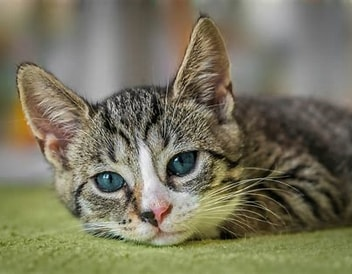

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
The image is CAT 🐱


In [73]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

input_image_path = input('Path of the image to be predicted: ')

# Read image (BGR)
input_image = cv2.imread(input_image_path)

# Show image
cv2_imshow(input_image)

# Convert BGR → RGB
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

# Resize
input_image_resize = cv2.resize(input_image, (224, 224))

# ❌ NO SCALING
# input_image_scaled = input_image_resize / 255

# Reshape
input_image_reshaped = np.expand_dims(input_image_resize, axis=0)

# Predict
prediction = model.predict(input_image_reshaped)

pred_label = np.argmax(prediction)

if pred_label == 0:
    print("The image is CAT 🐱")
else:
    print("The image is DOG 🐶")

In [74]:
model.save('model.keras')



In [75]:
from google.colab import files

files.download("model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
pip install gradio

In [77]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("model.keras")

def predict_image(img):
    # img is already a PIL Image object because type="pil"
    img = img.convert("RGB")
    img = img.resize((224, 224))

    img_array = np.array(img)   # Correct: raw images (0-255) are expected by the model's preprocess_input layer
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_id = np.argmax(prediction)

    print("Raw prediction:", prediction)

    return "Cat 🐱" if class_id == 0 else "Dog 🐶"

ui = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Label(label="Prediction"),
    title="Dog vs Cat Image Classifier",
    description="By Ashika Thakur"
)

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0e5b68f072ddf37e2f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
